In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')
# ----------------------------------------------------
# 0. MOCK DATA SETUP (Simulating the Kaggle Dataset)
# ----------------------------------------------------
np.random.seed(42)
n_samples = 200

data = {
    "Age": np.random.randint(29, 75, size=n_samples),
    "Sex": np.random.choice(["M", "F"], size=n_samples, p=[0.7, 0.3]),
    "ChestPainType": np.random.choice(
        ["ATA", "NAP", "ASY", "TA"], size=n_samples, p=[0.2, 0.2, 0.5, 0.1]
    ),
    "RestingBP": np.random.randint(90, 200, size=n_samples),
    "Cholesterol": np.random.randint(100, 400, size=n_samples),
    "HeartDisease": np.random.choice([0, 1], size=n_samples, p=[0.4, 0.6]),
}

df = pd.DataFrame(data)

# Injecting artifacts for the data cleaning demonstration
df.loc[10:14, "Cholesterol"] = np.nan  # Missing values
df.loc[25:27, "RestingBP"] = 0  # Structural errors (BP can't be 0)
df.loc[45, "Age"] = 150  # Extreme outlier
df = pd.concat([df, df.iloc[[12, 12, 50]]], ignore_index=True)  # Duplicates

print(f"Initial Shape: {df.shape}")
df.head(5)


Initial Shape: (203, 6)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,HeartDisease
0,67,M,TA,184,249.0,0
1,57,F,ASY,161,376.0,0
2,43,M,NAP,128,297.0,0
3,71,M,ATA,115,169.0,1
4,36,M,TA,123,211.0,1


In [3]:
# A. Drop Duplicates
print(f"Duplicates found: {df.duplicated().sum()}")
df = df.drop_duplicates().reset_index(drop=True)

# B. Handle Structural Errors (Logical zeros)
# Blood pressure cannot be 0. Replace with median.
df["RestingBP"] = df["RestingBP"].replace(0, np.nan)
df["RestingBP"] = df["RestingBP"].fillna(df["RestingBP"].median())

# C. Handle Outliers (Using IQR Method)
# Age 150 is impossible. Let's cap or remove using the IQR filter.
def remove_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return dataframe[
        (dataframe[column] >= lower_bound) & (dataframe[column] <= upper_bound)
    ]

def remove_outliers(dataframe,column):
    Q1= dataframe[column].quantile(0.25)
    Q2= dataframe[column].quantile(0.75)
    IQR= Q3-Q1
    lowerbound= Q1-1.5*IQR
    upper_bound= Q1+1.5*IQR
    return dataframe[(dataframe[column]>)]
    
df = remove_outliers_iqr(df, "Age")

# D. Handle Missing Values (Imputation)
# Continuous skewed fields get Median, normally distributed fields get Mean.
df["Cholesterol"] = df["Cholesterol"].fillna(df["Cholesterol"].median())

print(f"Cleaned Shape: {df.shape}")



Duplicates found: 3
Cleaned Shape: (199, 6)


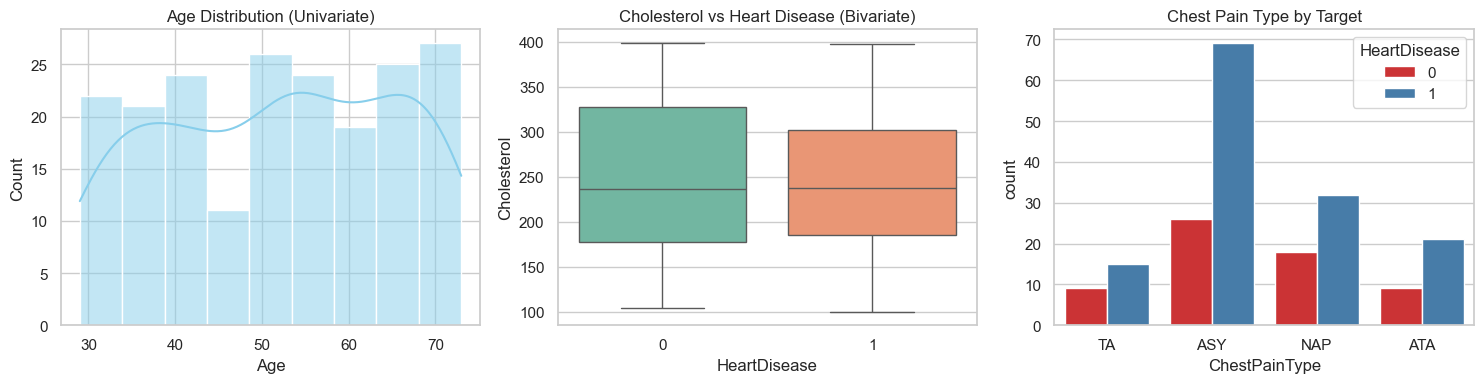

In [4]:
# Set visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 4))

# 1. Univariate Analysis (Distribution of a single column)
plt.subplot(1, 3, 1)
sns.histplot(df["Age"], kde=True, color="skyblue")
plt.title("Age Distribution (Univariate)")

# 2. Bivariate Analysis (Relationship between feature and target)
plt.subplot(1, 3, 2)
sns.boxplot(x="HeartDisease", y="Cholesterol", data=df, palette="Set2")
plt.title("Cholesterol vs Heart Disease (Bivariate)")

# 3. Categorical vs Categorical Interaction
plt.subplot(1, 3, 3)
sns.countplot(x="ChestPainType", hue="HeartDisease", data=df, palette="Set1")
plt.title("Chest Pain Type by Target")

plt.tight_layout()
plt.show()

In [5]:
# Create a risk flag combining Age and High Blood Pressure (Hypertension)
# Formula: If RestingBP > 140 and Age > 50, mark as High Risk (1), else (0)


def calculate_risk(row):
    if row["RestingBP"] > 140 and row["Age"] > 50:
        return 1
    return 0


df["Is_High_Risk_Demographic"] = df.apply(calculate_risk, axis=1)
print(df[["Age", "RestingBP", "Is_High_Risk_Demographic"]].head())

 

   Age  RestingBP  Is_High_Risk_Demographic
0   67      184.0                         1
1   57      161.0                         1
2   43      128.0                         0
3   71      115.0                         0
4   36      123.0                         0


In [6]:
# Create contingency table
contingency_table = pd.crosstab(
    df["Is_High_Risk_Demographic"], df["HeartDisease"]
)

# Run Chi-Square Test
chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-Square P-Value: {p_val:.4f}")

if p_val < 0.05:
    print("-> P < 0.05: Reject H0. Feature is STATISTICALLY VALUABLE. Keep it.")
else:
    print(
        "-> P >= 0.05: Fail to reject H0. Feature adds no statistical value. Drop it."
    )



Chi-Square P-Value: 1.0000
-> P >= 0.05: Fail to reject H0. Feature adds no statistical value. Drop it.


In [7]:
group_healthy = df[df["HeartDisease"] == 0]["Cholesterol"]
group_diseased = df[df["HeartDisease"] == 1]["Cholesterol"]

t_stat, p_val_t = stats.ttest_ind(group_healthy, group_diseased, equal_var=False)
print(f"T-Test P-Value: {p_val_t:.4f}")

if p_val_t < 0.05:
    print("-> Cholesterol levels differ significantly between targets. Keep it.")
else:
    print("-> Cholesterol levels do not differ cleanly. Consider dropping.")
df.head
 

T-Test P-Value: 0.5169
-> Cholesterol levels do not differ cleanly. Consider dropping.


<bound method NDFrame.head of      Age Sex ChestPainType  RestingBP  Cholesterol  HeartDisease  \
0     67   M            TA      184.0        249.0             0   
1     57   F           ASY      161.0        376.0             0   
2     43   M           NAP      128.0        297.0             0   
3     71   M           ATA      115.0        169.0             1   
4     36   M            TA      123.0        211.0             1   
..   ...  ..           ...        ...          ...           ...   
195   67   F           NAP      198.0        297.0             1   
196   30   M           NAP      159.0        260.0             1   
197   31   M           ASY      190.0        276.0             1   
198   65   M           ASY      122.0        384.0             1   
199   45   M           ATA      142.0        162.0             1   

     Is_High_Risk_Demographic  
0                           1  
1                           1  
2                           0  
3                        

In [8]:
# 1. Split into Features and Target
X = df.drop(columns=["HeartDisease"])
y = df["HeartDisease"]

# 2. Split into Train and Test FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Separate Columns by Type
num_cols = ["Age", "RestingBP", "Cholesterol"]
cat_cols = ["Sex", "ChestPainType"]
bin_cols = ["Is_High_Risk_Demographic"]

# 4. Handle Categorical Encoding (One-Hot Encoding)
encoder = OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore")

# Fit on TRAIN, transform both
X_train_encoded = encoder.fit_transform(X_train[cat_cols])
X_test_encoded = encoder.transform(X_test[cat_cols])

encoded_col_names = encoder.get_feature_names_out(cat_cols)
X_train_cat_df = pd.DataFrame(
    X_train_encoded, columns=encoded_col_names, index=X_train.index
)
X_test_cat_df = pd.DataFrame(
    X_test_encoded, columns=encoded_col_names, index=X_test.index
)

# 5. Feature Scaling (Standardization)
scaler = StandardScaler()

# Fit on TRAIN, transform both
X_train_scaled = scaler.fit_transform(X_train[num_cols])
X_test_scaled = scaler.transform(X_test[num_cols])

X_train_num_df = pd.DataFrame(
    X_train_scaled, columns=num_cols, index=X_train.index
)
X_test_num_df = pd.DataFrame(X_test_scaled, columns=num_cols, index=X_test.index)

# 6. Combine everything back together cleanly
X_train_final = pd.concat(
    [X_train_num_df, X_train_cat_df, X_train[bin_cols]], axis=1
)
X_test_final = pd.concat([X_test_num_df, X_test_cat_df, X_test[bin_cols]], axis=1)

print("\nFinal Processed Training Features Example:")
print(X_train_final.head(2))



Final Processed Training Features Example:
          Age  RestingBP  Cholesterol  Sex_M  ChestPainType_ATA  \
152  0.336922   1.302685     0.732735    0.0                0.0   
123  0.781492  -0.613186     0.940069    1.0                0.0   

     ChestPainType_NAP  ChestPainType_TA  Is_High_Risk_Demographic  
152                1.0               0.0                         1  
123                0.0               0.0                         0  


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# 1. Split Features and Target
target_column = "HeartDisease" # Change this for other projects
X = df.drop(columns=[target_column])
y = df[target_column]

# 2. Automatically identify column types
# This makes it work for ANY dataset without manual listing
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns

# 3. Create Transformers
# Added 'SimpleImputer' because real-world data often has missing values (NaNs)
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# 4. Bundle them into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ],
    remainder='passthrough' # Keeps columns like "Is_High_Risk_Demographic" as they are
)

# 5. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Run the entire "Prep Station" in 2 lines
X_train_final = preprocessor.fit_transform(X_train)
X_test_final = preprocessor.transform(X_test)

# Convert back to DataFrame to see the results clearly
feature_names = preprocessor.get_feature_names_out()
X_train_final = pd.DataFrame(X_train_final, columns=feature_names, index=X_train.index)

print(X_train_final.head())

     num__RestingBP  num__Cholesterol  num__Is_High_Risk_Demographic  \
184       -0.470743         -0.864917                      -0.707107   
38         0.191072         -1.730092                      -0.707107   
24         0.569252          0.526377                       1.414214   
143       -0.029533         -1.613176                       1.414214   
142        0.065012         -0.011434                       1.414214   

     cat__Sex_M  cat__ChestPainType_ATA  cat__ChestPainType_NAP  \
184         1.0                     0.0                     0.0   
38          1.0                     1.0                     0.0   
24          1.0                     0.0                     1.0   
143         0.0                     1.0                     0.0   
142         0.0                     0.0                     0.0   

     cat__ChestPainType_TA  remainder__Age  
184                    0.0            65.0  
38                     0.0            49.0  
24                     0.0   